# Unemployment Analysis in India with Python

Unemployment rate = % of people who are unemployed out of the total labour force.

This notebook analyzes the unemployment rate in India, including the sharp spike during COVID-19.

Dataset: [Kaggle - Unemployment in India](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india)

## 1. Upload / Load the Dataset

Download `Unemployment in India.csv` from the Kaggle link above and upload it to Colab, or use the Kaggle API.

In [ ]:
# Option 1: Upload the file manually (uncomment to use in Colab)
# from google.colab import files
# uploaded = files.upload()  # select 'Unemployment in India.csv'

## 2. Load the Dataset Directly using KaggleHub

In [ ]:
import pandas as pd
import os
import zipfile

# Define the path to the local zip file
zip_file_path = '/content/archive (1).zip'
# Define the directory where the contents will be extracted
extract_dir = '/content/unemployment_data_local'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Construct the full path to the specific CSV file within the extracted content
file_name = 'Unemployment in India.csv'
file_path = os.path.join(extract_dir, file_name)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully from local file: {file_path}")

Dataset loaded successfully from local file: /content/unemployment_data_local/Unemployment in India.csv


In [ ]:
# Display the first 5 rows of the loaded DataFrame
display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Explore and Clean the Data

In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
# Strip extra whitespace from column names
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
# Check for missing values
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
# Drop rows with missing values (if any)
df = df.dropna()
df.shape

(740, 7)

In [ ]:
# Strip whitespace from string/categorical columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df.head()

/tmp/ipykernel_2958/2585903969.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.strip()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", dayfirst=True, errors="coerce")

# Extract month name and year for grouping
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%B")
df["Year"] = df["Date"].dt.year

df.head()

/tmp/ipykernel_2958/269004717.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", dayfirst=True, errors="coerce")
/tmp/ipykernel_2958/269004717.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Date"].dt.month
/tmp/ipykernel_2958/269004717.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Month_Name,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,September,2019


In [ ]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Month,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


### Summary Statistics of the Data

In [ ]:
display(df.describe(include='all'))

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
count,740,740,740,740.000000,7.400000e+02,740.000000,740
unique,28,14,2,NaN,NaN,NaN,2
top,Andhra Pradesh,31-10-2019,Monthly,NaN,NaN,NaN,Urban
freq,28,55,381,NaN,NaN,NaN,381
mean,NaN,NaN,NaN,11.787946,7.204460e+06,42.630122,NaN
std,NaN,NaN,NaN,10.721298,8.087988e+06,8.111094,NaN
min,NaN,NaN,NaN,0.000000,4.942000e+04,13.330000,NaN
25%,NaN,NaN,NaN,4.657500,1.190404e+06,38.062500,NaN
50%,NaN,NaN,NaN,8.350000,4.744178e+06,41.160000,NaN
75%,NaN,NaN,NaN,15.887500,1.127549e+07,45.505000,NaN


## 3. Overall Unemployment Rate Trend Over Time

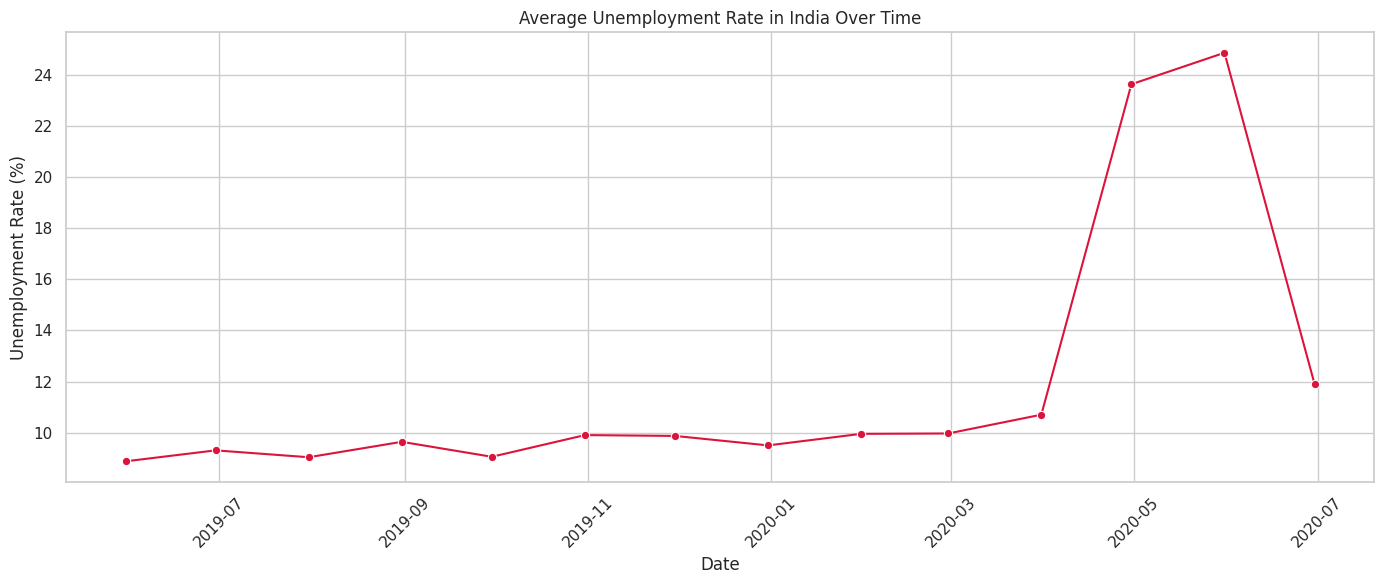

In [ ]:
unemployment_col = "Estimated Unemployment Rate (%)"

monthly_avg = df.groupby("Date")[unemployment_col].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_avg, x="Date", y=unemployment_col, marker="o", color="crimson")
plt.title("Average Unemployment Rate in India Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Notice the sharp spike around **April-May 2020**, corresponding to the COVID-19 lockdown.

## 4. Unemployment Rate by Region (State)

/tmp/ipykernel_2958/265720297.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_avg, x=unemployment_col, y="Region", palette="viridis")


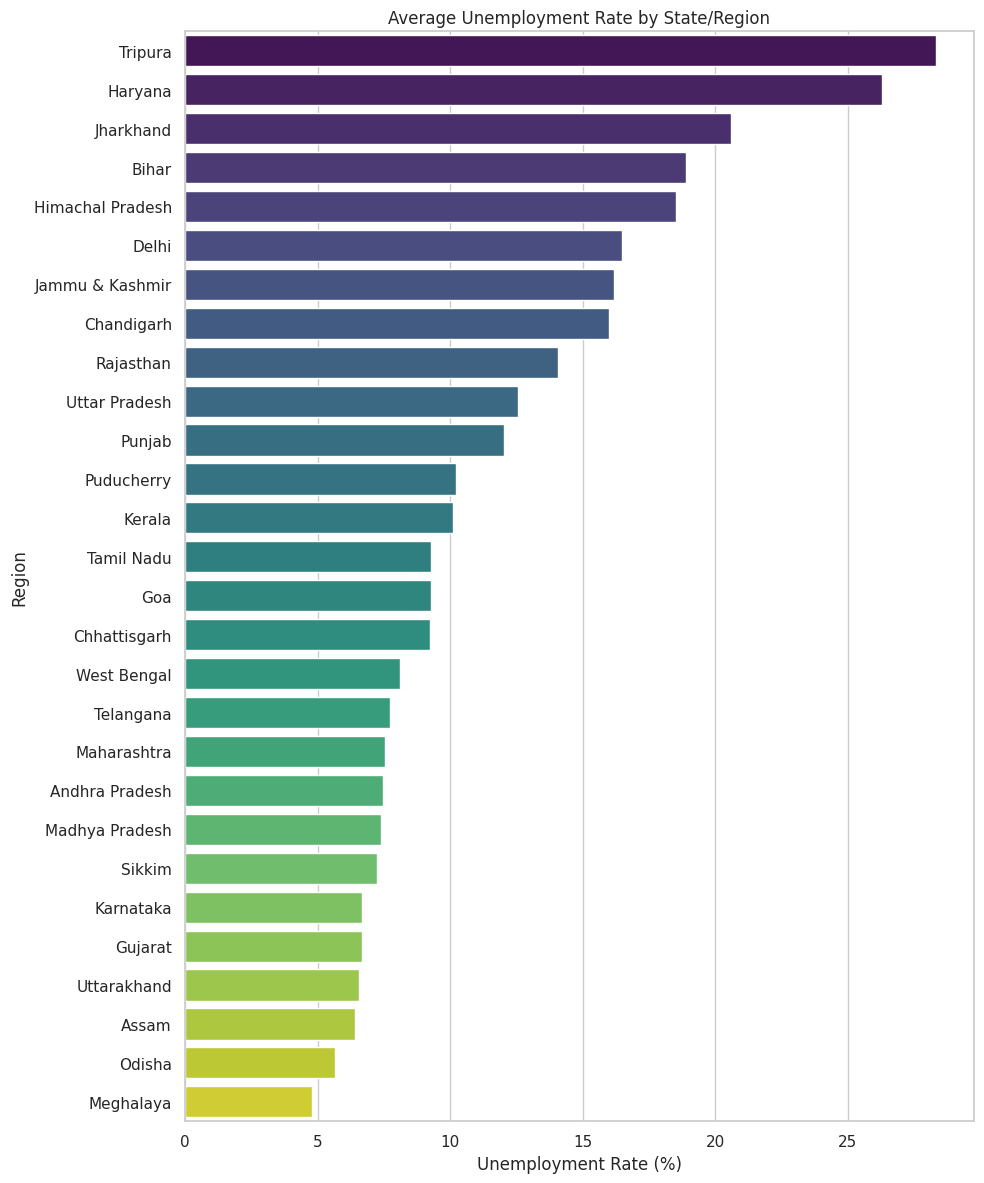

In [ ]:
region_avg = df.groupby("Region")[unemployment_col].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 12))
sns.barplot(data=region_avg, x=unemployment_col, y="Region", palette="viridis")
plt.title("Average Unemployment Rate by State/Region")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## 5. Unemployment Rate Over Time by Region (Top States)

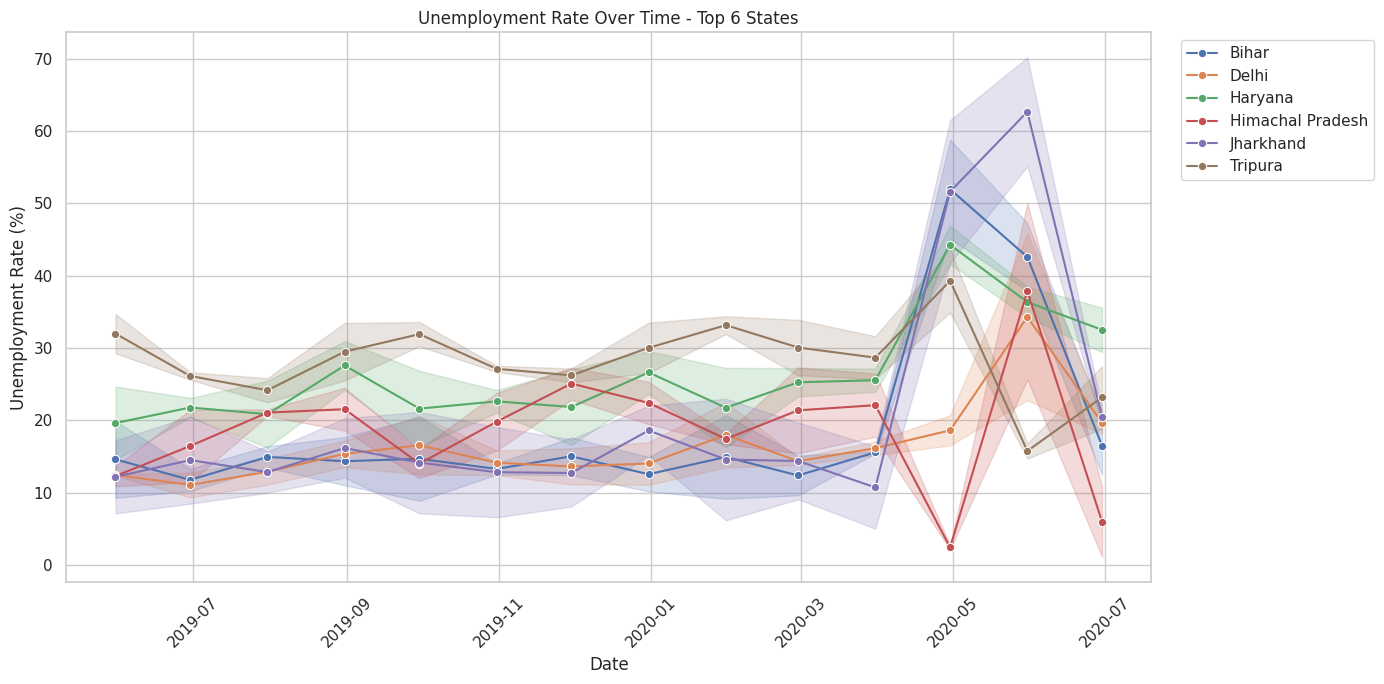

In [ ]:
top_states = region_avg["Region"].head(6).tolist()
subset = df[df["Region"].isin(top_states)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=subset, x="Date", y=unemployment_col, hue="Region", marker="o")
plt.title("Unemployment Rate Over Time - Top 6 States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6. Impact of COVID-19 (Before vs During Lockdown)

In [ ]:
# Define lockdown period (approx. India's first lockdown: April-May 2020)
lockdown_start = pd.Timestamp("2020-04-01")
lockdown_end = pd.Timestamp("2020-05-31")

df["Period"] = np.where(
    (df["Date"] >= lockdown_start) & (df["Date"] <= lockdown_end),
    "During Lockdown",
    "Other"
)

period_avg = df.groupby("Period")[unemployment_col].mean()
period_avg

/tmp/ipykernel_2958/3481541600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Period"] = np.where(


,Estimated Unemployment Rate (%)
Period,
During Lockdown,24.258431
Other,9.794232


/tmp/ipykernel_2958/1848029400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=period_avg.index, y=period_avg.values, palette="Set2")


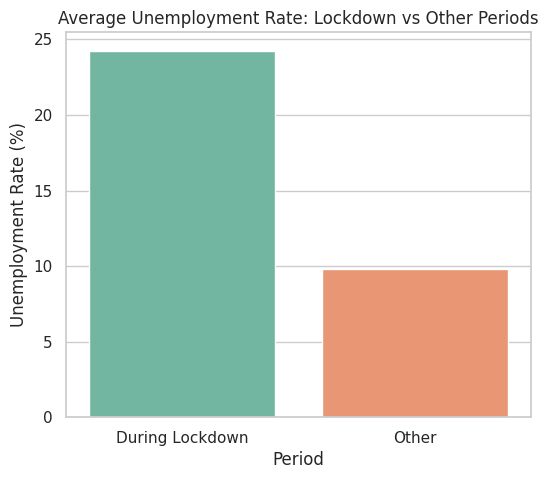

In [ ]:
plt.figure(figsize=(6, 5))
sns.barplot(x=period_avg.index, y=period_avg.values, palette="Set2")
plt.title("Average Unemployment Rate: Lockdown vs Other Periods")
plt.ylabel("Unemployment Rate (%)")
plt.show()

## 7. Unemployment Rate by Area (Rural vs Urban)

(If the dataset includes an `Area` column for Rural/Urban breakdown)

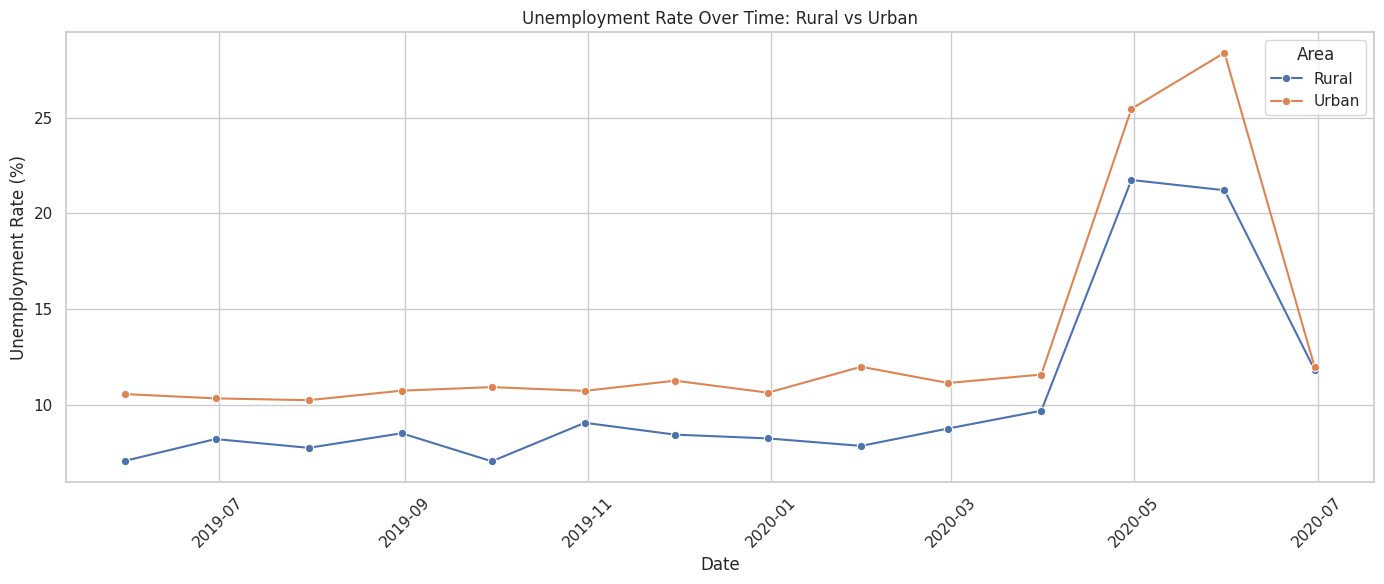

In [ ]:
if "Area" in df.columns:
    area_avg = df.groupby(["Area", "Date"])[unemployment_col].mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=area_avg, x="Date", y=unemployment_col, hue="Area", marker="o")
    plt.title("Unemployment Rate Over Time: Rural vs Urban")
    plt.xlabel("Date")
    plt.ylabel("Unemployment Rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No 'Area' column found in this dataset.")

## 8. Interactive Visualization with Plotly

In [ ]:
fig = px.line(
    df.sort_values("Date"),
    x="Date",
    y=unemployment_col,
    color="Region",
    title="Unemployment Rate in India by Region Over Time"
)
fig.update_layout(xaxis_title="Date", yaxis_title="Unemployment Rate (%)")
fig.show()

In [ ]:
fig2 = px.bar(
    region_avg,
    x="Region",
    y=unemployment_col,
    color=unemployment_col,
    color_continuous_scale="Reds",
    title="Average Unemployment Rate by Region"
)
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()

## 9. Correlation Between Numeric Features

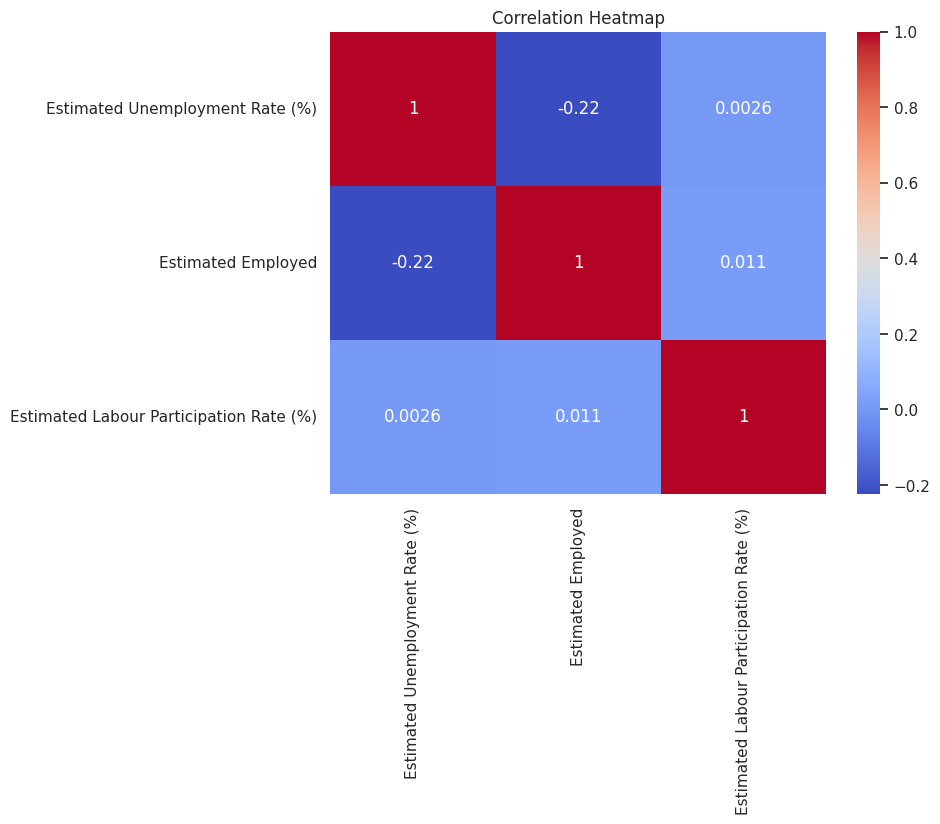

In [ ]:
numeric_df = df.select_dtypes(include=["float64", "int64"])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 10. Conclusion

- We cleaned and explored India's unemployment dataset.
- The overall unemployment rate showed a **sharp spike around April-May 2020**, coinciding with the COVID-19 lockdown.
- Some states/regions consistently show higher unemployment rates than others.
- Rural and urban areas (where available) show different unemployment trends.
- Interactive Plotly charts allow further exploration of trends across time and regions.